In [ ]:
import pandas as pd              # untuk mengolah data tabel (DataFrame)
import numpy as np               # untuk operasi numerik / perhitungan
import matplotlib.pyplot as plt  # untuk membuat grafik / visualisasi

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler  # untuk normalisasi data
from sklearn.cluster import KMeans                # algoritma clustering K-Means
from sklearn.metrics import davies_bouldin_score  # untuk evaluasi kualitas cluster (DBI)


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving finaldataset.xlsx to finaldataset.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel('finaldataset.xlsx')
df.head()

,Produk,Varian,Jumlah Terjual,Total Penjualan,Harga Pokok Penjualan,Laba,Rata-rata Qty Terjual,Bulan,Tahun
0,Additional,Caramel,26,128500,0,128500,1.04,1,2024
1,Additional,Hazelnut,16,80000,0,80000,1.00,1,2024
2,Additional,SKM,12,60000,0,60000,1.09,1,2024
3,Additional,Swap to Vegan Milk,4,40000,0,40000,1.00,1,2024
4,Additional,Vanilla,9,45000,0,45000,1.00,1,2024


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2053 entries, 0 to 2052
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Produk                 2053 non-null   object 
 1   Varian                 2053 non-null   object 
 2   Jumlah Terjual         2053 non-null   int64  
 3   Total Penjualan        2053 non-null   int64  
 4   Harga Pokok Penjualan  2053 non-null   int64  
 5   Laba                   2053 non-null   int64  
 6   Rata-rata Qty Terjual  2053 non-null   float64
 7   Bulan                  2053 non-null   int64  
 8   Tahun                  2053 non-null   int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 144.5+ KB


In [ ]:
df.isnull().sum()

,0
Produk,0
Varian,0
Jumlah Terjual,0
Total Penjualan,0
Harga Pokok Penjualan,0
Laba,0
Rata-rata Qty Terjual,0
Bulan,0
Tahun,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Jumlah Terjual,Total Penjualan,Harga Pokok Penjualan,Laba,Rata-rata Qty Terjual,Bulan,Tahun
count,2053.000000,2.053000e+03,2.053000e+03,2.053000e+03,2053.000000,2053.000000,2053.000000
mean,45.701413,1.125694e+06,6.807620e+04,1.057633e+06,1.103059,6.676571,2024.482708
std,55.986362,1.439796e+06,3.601662e+05,1.428852e+06,0.933336,3.479349,0.499823
min,1.000000,0.000000e+00,0.000000e+00,-3.781000e+05,0.860000,1.000000,2024.000000
25%,10.000000,2.320000e+05,0.000000e+00,1.980000e+05,1.000000,4.000000,2024.000000
50%,26.000000,6.540000e+05,0.000000e+00,5.600000e+05,1.050000,7.000000,2024.000000
75%,62.000000,1.441500e+06,0.000000e+00,1.350000e+06,1.120000,10.000000,2025.000000
max,487.000000,1.347700e+07,3.900000e+06,1.347700e+07,43.000000,12.000000,2025.000000


In [ ]:
df = df[['Produk', 'Varian', 'Jumlah Terjual', 'Total Penjualan',
         'Laba', 'Rata-rata Qty Terjual', 'Bulan', 'Tahun']]
df.head()

,Produk,Varian,Jumlah Terjual,Total Penjualan,Laba,Rata-rata Qty Terjual,Bulan,Tahun
0,Additional,Caramel,26,128500,128500,1.04,1,2024
1,Additional,Hazelnut,16,80000,80000,1.00,1,2024
2,Additional,SKM,12,60000,60000,1.09,1,2024
3,Additional,Swap to Vegan Milk,4,40000,40000,1.00,1,2024
4,Additional,Vanilla,9,45000,45000,1.00,1,2024


In [ ]:
# =========================
# 5. ENCODING Transformasi
# =========================
le_produk = LabelEncoder()
le_varian = LabelEncoder()

df['Produk'] = le_produk.fit_transform(df['Produk'])
df['Varian'] = le_varian.fit_transform(df['Varian'])

print("\n=== SETELAH ENCODING ===")
print(df.head())


=== SETELAH ENCODING ===
   Produk  Varian  Jumlah Terjual  Total Penjualan    Laba  \
0       2      46              26           128500  128500   
1       2      95              16            80000   80000   
2       2     192              12            60000   60000   
3       2     221               4            40000   40000   
4       2     238               9            45000   45000   

   Rata-rata Qty Terjual  Bulan  Tahun  
0                   1.04      1   2024  
1                   1.00      1   2024  
2                   1.09      1   2024  
3                   1.00      1   2024  
4                   1.00      1   2024  


In [ ]:
# ==============================
# 3. PENENTUAN K DAN EVALUASI DBI
# ==============================
X = df[['Produk', 'Varian', 'Jumlah Terjual',
        'Total Penjualan', 'Laba',
        'Rata-rata Qty Terjual', 'Bulan', 'Tahun']]

results = []

print("\n=== Evaluasi DBI untuk K 2-10 ===")
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    dbi = davies_bouldin_score(X, labels)
    results.append([k, dbi])
    print(f"K = {k}, DBI = {dbi:.4f}")

df_results = pd.DataFrame(results, columns=['K', 'DBI'])
optimal_k = df_results.loc[df_results['DBI'].idxmin(), 'K']

print("\nK Optimal:", optimal_k)
print("Nilai DBI Terendah:", df_results['DBI'].min())


=== Evaluasi DBI untuk K 2-15 ===
K = 2, DBI = 0.5499
K = 3, DBI = 0.5359
K = 4, DBI = 0.5304
K = 5, DBI = 0.5457
K = 6, DBI = 0.5691
K = 7, DBI = 0.5485
K = 8, DBI = 0.5368
K = 9, DBI = 0.5157
K = 10, DBI = 0.5125

K Optimal: 10
Nilai DBI Terendah: 0.512455224648296

=== Evaluasi DBI untuk K 2-15 ===
K = 2, DBI = 0.5499
K = 3, DBI = 0.5359
K = 4, DBI = 0.5304
K = 5, DBI = 0.5457
K = 6, DBI = 0.5691
K = 7, DBI = 0.5485
K = 8, DBI = 0.5368
K = 9, DBI = 0.5157
K = 10, DBI = 0.5125

K Optimal: 10
Nilai DBI Terendah: 0.512455224648296


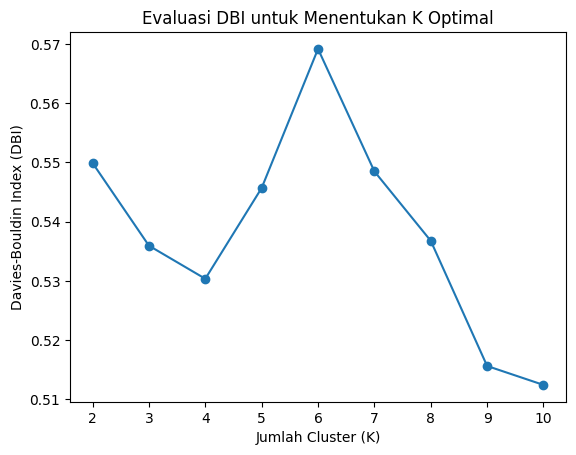


K Optimal: 10
Nilai DBI Terendah: 0.512455224648296


In [ ]:
# ==============================
# 6. VISUALISASI DBI
# ==============================
plt.figure()
plt.plot(df_results['K'], df_results['DBI'], marker='o')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Davies-Bouldin Index (DBI)')
plt.title('Evaluasi DBI untuk Menentukan K Optimal')
plt.show()


# ==============================
# 7. AMBIL K TERBAIK
# ==============================
optimal_k = df_results.loc[df_results['DBI'].idxmin(), 'K']

print("\nK Optimal:", optimal_k)
print("Nilai DBI Terendah:", df_results['DBI'].min())


In [ ]:
# ==============================
# 4. K-MEANS DENGAN K OPTIMAL
# ==============================
kmeans_optimal = KMeans(n_clusters=int(optimal_k), random_state=42, n_init=10)
df['Cluster'] = kmeans_optimal.fit_predict(X)

# ==============================
# 5. JUMLAH ANGGOTA TIAP CLUSTER
# ==============================
cluster_counts = df['Cluster'].value_counts().sort_index()
print("\n=== Jumlah Anggota per Cluster ===")
print(cluster_counts)


=== Jumlah Anggota per Cluster ===
Cluster
0    200
1    861
2     19
3     64
4    327
5     24
6    113
7      6
8     37
9    402
Name: count, dtype: int64


In [ ]:
print(df.head())

   Produk  Varian  Jumlah Terjual  Total Penjualan    Laba  \
0       2      46              26           128500  128500   
1       2      95              16            80000   80000   
2       2     192              12            60000   60000   
3       2     221               4            40000   40000   
4       2     238               9            45000   45000   

   Rata-rata Qty Terjual  Bulan  Tahun  Cluster  
0                   1.04      1   2024        1  
1                   1.00      1   2024        1  
2                   1.09      1   2024        1  
3                   1.00      1   2024        1  
4                   1.00      1   2024        1  


In [ ]:
# ==============================
# 1. STATISTIK PER CLUSTER (Atribut Utama)
# ==============================
main_features = ['Rata-rata Qty Terjual', 'Jumlah Terjual', 'Total Penjualan', 'Laba']

for cluster_id in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster_id]

    print(f"\n===== CLUSTER {cluster_id} =====")
    for feature in main_features:
        min_val = cluster_data[feature].min()
        max_val = cluster_data[feature].max()
        mean_val = cluster_data[feature].mean()
        print(f"{feature:20}: Min = {min_val:.2f}, Max = {max_val:.2f}, Mean = {mean_val:.2f}")


===== CLUSTER 0 =====
Rata-rata Qty Terjual: Min = 1.00, Max = 1.96, Mean = 1.12
Jumlah Terjual      : Min = 33.00, Max = 154.00, Mean = 86.19
Total Penjualan     : Min = 1601250.00, Max = 2884000.00, Mean = 1985630.70
Laba                : Min = 1601250.00, Max = 2470000.00, Mean = 1973946.20

===== CLUSTER 1 =====
Rata-rata Qty Terjual: Min = 0.86, Max = 2.67, Mean = 1.05
Jumlah Terjual      : Min = 1.00, Max = 121.00, Mean = 10.20
Total Penjualan     : Min = 0.00, Max = 914700.00, Mean = 197935.86
Laba                : Min = -195300.00, Max = 428800.00, Mean = 178579.90

===== CLUSTER 2 =====
Rata-rata Qty Terjual: Min = 1.10, Max = 1.30, Mean = 1.18
Jumlah Terjual      : Min = 243.00, Max = 352.00, Mean = 281.53
Total Penjualan     : Min = 7224000.00, Max = 9405000.00, Mean = 8110315.79
Laba                : Min = 6210920.00, Max = 9405000.00, Mean = 8012311.58

===== CLUSTER 3 =====
Rata-rata Qty Terjual: Min = 1.02, Max = 1.45, Mean = 1.12
Jumlah Terjual      : Min = 114.00, Max

In [ ]:
# ==============================
# 2. INTERPRETASI / KATEGORI CLUSTER
# ==============================
cluster_categories = []

for cluster_id in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster_id]

    total_mean = cluster_data['Total Penjualan'].mean()
    laba_mean = cluster_data['Laba'].mean()

    if total_mean > df['Total Penjualan'].mean() and laba_mean > df['Laba'].mean():
        kategori = "High Sales"
    elif total_mean < df['Total Penjualan'].mean() and laba_mean < df['Laba'].mean():
        kategori = "Low Sales"
    else:
        kategori = "Medium Sales"

    cluster_categories.append({'Cluster': cluster_id, 'Kategori': kategori})

# Tampilkan hasil kategori cluster
import pandas as pd
df_categories = pd.DataFrame(cluster_categories)
print("\n=== Kategori Cluster ===")
print(df_categories)


=== Kategori Cluster ===
   Cluster      Kategori
0        0    High Sales
1        1     Low Sales
2        2    High Sales
3        3    High Sales
4        4    High Sales
5        5    High Sales
6        6    High Sales
7        7    High Sales
8        8  Medium Sales
9        9     Low Sales
